# Exercise 3: Nitrification in a Biofilm-Fluidized Bed Reactor

Nitrification is modeled as a two-step sequential oxidation:

$$\text{NH}_4^+ + O_2 \rightarrow \text{NO}_2^-$$
$$\text{NO}_2^- + O_2 \rightarrow \text{NO}_3^-$$

**Species:**
- $S_1$: NH₄⁺ (ammonium)
- $S_2$: NO₂⁻ (nitrite)
- $S_3$: NO₃⁻ (nitrate)
- $C_L$: dissolved oxygen

**Kinetics (double Monod):**
$$r_1 = v_{m1} \frac{S_1}{K_1 + S_1} \frac{C_L}{K_{O1} + C_L}$$
$$r_2 = v_{m2} \frac{S_2}{K_2 + S_2} \frac{C_L}{K_{O2} + C_L}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
vm1  = 125.0   # h⁻¹, max reaction rate step 1 (NH4+ → NO2-)
vm2  =  75.0   # h⁻¹, max reaction rate step 2 (NO2- → NO3-)
K1   =   5.0   # mg/L, half-saturation S1
K2   =   3.0   # mg/L, half-saturation S2
KO1  =   0.25  # mg/L, O2 half-saturation step 1
KO2  =   0.50  # mg/L, O2 half-saturation step 2
YO1  =   3.5   # mg O2 / mg S1  (Y_O/S1)
YO2  =   1.1   # mg O2 / mg S2  (Y_O/S2)
CL_star = 8.0  # mg/L, O2 saturation concentration

# Initial conditions
S1_0  = 100.0  # mg/L  NH4+
S2_0  =   0.0  # mg/L  NO2-
S3_0  =   0.0  # mg/L  NO3-
CL_0  =   7.0  # mg/L  dissolved O2

print("Parameters loaded successfully.")

Parameters loaded successfully.



## Part (a) Concentration Balances:

For a **batch system** with oxygen transfer from gas to liquid:

$$\frac{dS_1}{dt} = -r_1$$

$$\frac{dS_2}{dt} = r_1 - r_2$$

$$\frac{dS_3}{dt} = r_2$$

$$\frac{dC_L}{dt} = k_La\,(C_L^* - C_L) - Y_{O/S_1}\,r_1 - Y_{O/S_2}\,r_2$$

- $r_1$ consumes $S_1$ and produces $S_2$; it consumes $Y_{O/S_1}\cdot r_1$ of oxygen.
- $r_2$ consumes $S_2$ and produces $S_3$; it consumes $Y_{O/S_2}\cdot r_2$ of oxygen.
- The $k_La$ term replenishes dissolved oxygen from the gas phase.

In [ ]:
def reaction_rates(S1, S2, CL):

    r1 = vm1 * (S1 / (K1 + S1)) * (CL / (KO1 + CL))
    r2 = vm2 * (S2 / (K2 + S2)) * (CL / (KO2 + CL))
    return r1, r2


def odes(t, y, kLa):

    S1, S2, S3, CL = y
    # Clamp negatives (numerical safety)
    S1 = max(S1, 0.0)
    S2 = max(S2, 0.0)
    S3 = max(S3, 0.0)
    CL = max(CL, 0.0)

    r1, r2 = reaction_rates(S1, S2, CL)

    dS1 = -r1
    dS2 =  r1 - r2
    dS3 =  r2
    dCL =  kLa * (CL_star - CL) - YO1 * r1 - YO2 * r2

    return [dS1, dS2, dS3, dCL]


def simulate(kLa, t_end=3.0, n_points=6000):

    y0     = [S1_0, S2_0, S3_0, CL_0]
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, n_points)
    sol = solve_ivp(odes, t_span, y0, method='BDF',
                    args=(kLa,), t_eval=t_eval,
                    rtol=1e-8, atol=1e-8)
    return sol

print("ODE system and helper functions defined.")

ODE system and helper functions defined.



## Part (b) Find k_La to Keep C_L > K_O1:

The process is **oxygen-limited** when $C_L \leq K_{O1} = 0.25$ mg/L.  
We sweep $k_La \in [1, 100]$ h⁻¹ and record the **minimum** $C_L$ over the entire simulation.

Minimum k_La to avoid oxygen limitation: ~29.9 h⁻¹


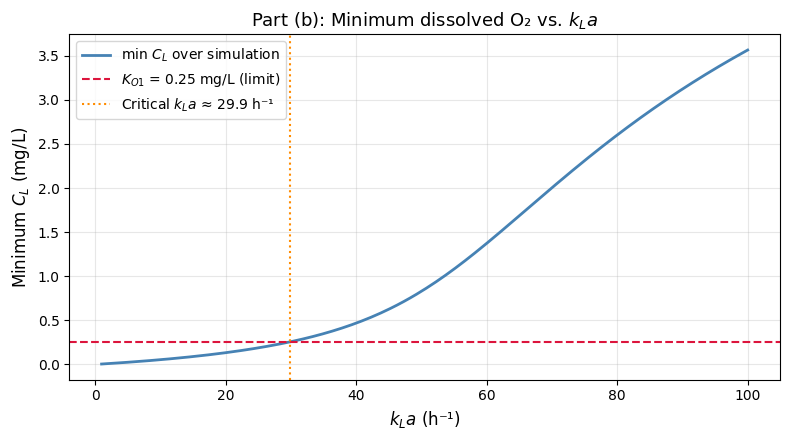


Conclusion: k_La ≥ 29.9 h⁻¹ keeps C_L above K_O1 throughout the process.


In [3]:
kLa_values = np.linspace(1, 100, 200)   # h⁻¹
min_CL     = []

for kLa in kLa_values:
    sol = simulate(kLa, t_end=3.0)
    min_CL.append(np.min(sol.y[3]))      # index 3 = CL

min_CL = np.array(min_CL)

# critical kLa (first value where min_CL > KO1)
critical_mask  = min_CL > KO1
kLa_critical   = kLa_values[critical_mask][0] if critical_mask.any() else None
print(f"Minimum k_La to avoid oxygen limitation: ~{kLa_critical:.1f} h⁻¹")

#Plots
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(kLa_values, min_CL, lw=2, color='steelblue', label='min $C_L$ over simulation')
ax.axhline(KO1, color='crimson', ls='--', lw=1.5, label=f'$K_{{O1}}$ = {KO1} mg/L (limit)')
if kLa_critical is not None:
    ax.axvline(kLa_critical, color='darkorange', ls=':', lw=1.5,
               label=f'Critical $k_La$ ≈ {kLa_critical:.1f} h⁻¹')
ax.set_xlabel('$k_La$ (h⁻¹)', fontsize=12)
ax.set_ylabel('Minimum $C_L$ (mg/L)', fontsize=12)
ax.set_title('Part (b): Minimum dissolved O₂ vs. $k_La$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nConclusion: k_La ≥ {kLa_critical:.1f} h⁻¹ keeps C_L above K_O1 throughout the process.")

## Part (c) Time for S1 to reach zero (no O₂ limitation) & full species plot:

**No oxygen limitation** means $C_L \gg K_{O1}$, i.e. the oxygen Monod factor $\approx 1$.  
We simulate with the critical $k_La$ found in (b) **and** with a very large $k_La$ (= 10 000 h⁻¹, approximating infinite aeration) to estimate the theoretical minimum time.

Approximate time for S1 → 0 (no O₂ limitation): 60.4 min  (1.0069 h)


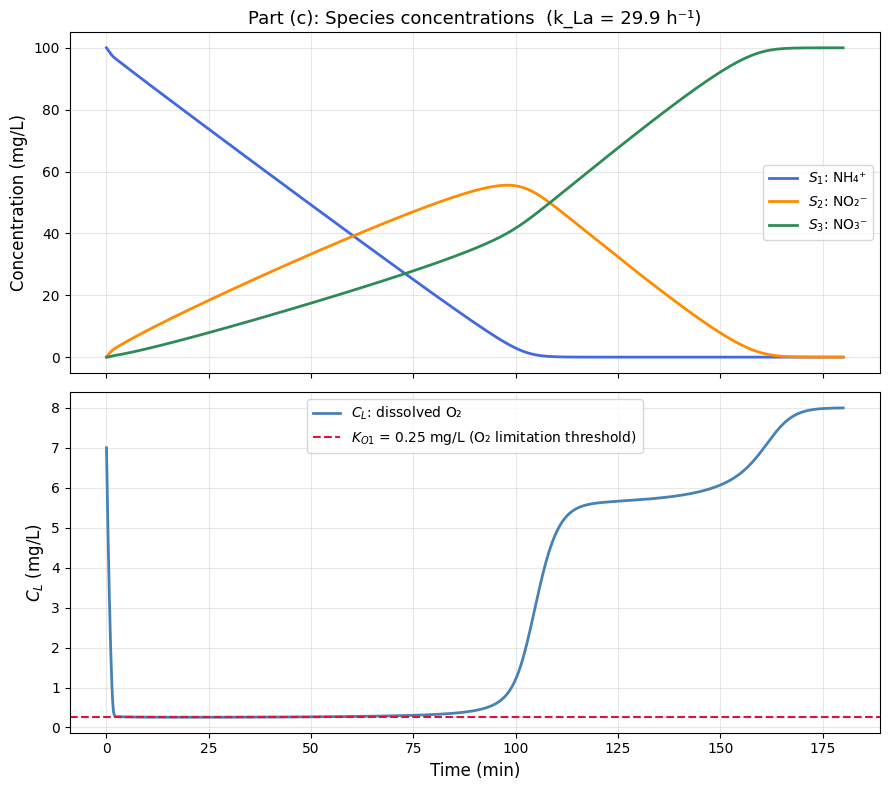

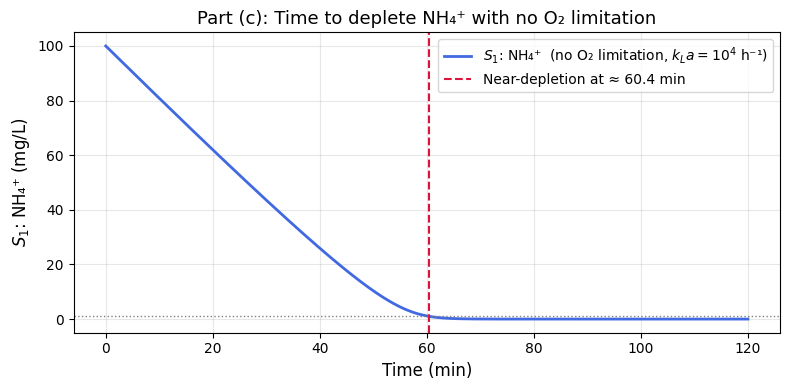


Summary:
  - S1 depleted (< 1.0 mg/L) at t ≈ 60.4 min without O₂ limitation.
  - Critical k_La = 29.9 h⁻¹ keeps C_L > K_O1 = 0.25 mg/L throughout.


In [4]:
# (i) No-limitation case: very high kLa
kLa_nolim = 1e4   # h⁻¹ — effectively pins CL = CL*
sol_nolim  = simulate(kLa_nolim, t_end=2.0, n_points=10000)

S1_nolim = sol_nolim.y[0]
t_nolim  = sol_nolim.t

# Time when S1 first drops below 1 % of initial value (≈ 'zero')
threshold   = 1.0   # mg/L  — near depletion
idx_zero    = np.argmax(S1_nolim < threshold)
t_depletion = t_nolim[idx_zero]
print(f"Approximate time for S1 → 0 (no O₂ limitation): {t_depletion*60:.1f} min  ({t_depletion:.4f} h)")

# (ii) Simulation with critical kLa from part (b)
sol_crit = simulate(kLa_critical, t_end=3.0, n_points=10000)

# Plot species for critical kLa 
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

t_c = sol_crit.t * 60   # convert to minutes for readability
S1_c, S2_c, S3_c, CL_c = sol_crit.y

# Nitrogen species
ax0 = axes[0]
ax0.plot(t_c, S1_c, lw=2, color='royalblue',   label='$S_1$: NH₄⁺')
ax0.plot(t_c, S2_c, lw=2, color='darkorange',  label='$S_2$: NO₂⁻')
ax0.plot(t_c, S3_c, lw=2, color='seagreen',    label='$S_3$: NO₃⁻')
ax0.set_ylabel('Concentration (mg/L)', fontsize=12)
ax0.set_title(f'Part (c): Species concentrations  (k_La = {kLa_critical:.1f} h⁻¹)', fontsize=13)
ax0.legend(fontsize=10)
ax0.grid(True, alpha=0.3)

# Dissolved oxygen
ax1 = axes[1]
ax1.plot(t_c, CL_c, lw=2, color='steelblue', label='$C_L$: dissolved O₂')
ax1.axhline(KO1, color='crimson', ls='--', lw=1.5,
            label=f'$K_{{O1}}$ = {KO1} mg/L (O₂ limitation threshold)')
ax1.set_xlabel('Time (min)', fontsize=12)
ax1.set_ylabel('$C_L$ (mg/L)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Annotate depletion time on a separate clean S1 plot
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(t_nolim * 60, S1_nolim, lw=2, color='royalblue',
         label='$S_1$: NH₄⁺  (no O₂ limitation, $k_La = 10^4$ h⁻¹)')
ax2.axhline(threshold, color='grey', ls=':', lw=1)
ax2.axvline(t_depletion * 60, color='crimson', ls='--', lw=1.5,
            label=f'Near-depletion at ≈ {t_depletion*60:.1f} min')
ax2.set_xlabel('Time (min)', fontsize=12)
ax2.set_ylabel('$S_1$: NH₄⁺ (mg/L)', fontsize=12)
ax2.set_title('Part (c): Time to deplete NH₄⁺ with no O₂ limitation', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  - S1 depleted (< {threshold} mg/L) at t ≈ {t_depletion*60:.1f} min without O₂ limitation.")
print(f"  - Critical k_La = {kLa_critical:.1f} h⁻¹ keeps C_L > K_O1 = {KO1} mg/L throughout.")